# 05 random forest

In [1]:
from pathlib import Path

# Works whether the notebook is run from the project root or from the notebooks folder.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


## imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score,
                              f1_score, roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from sklearn.inspection import permutation_importance

import shap
import lime
import lime.lime_tabular

## load processed dataset

In [3]:
df = pd.read_csv(DATA_DIR / "processed_carbon_dataset.csv")

feature_cols = [  # unified 15-feature set
    "electricity_kwh_per_month", "natural_gas_therms_per_month",
    "fuel_liters_per_month", "car_km_per_month",
    "public_transport_km_per_month", "meat_kg_per_month",
    "energy_per_person", "gas_per_person",
    "fuel_per_person", "car_per_person",
    "transport_ratio", "meat_per_person",
    "food_per_person", "waste_per_person", "log_income"
]

X = df[feature_cols]
y = df["carbon_level"]


## train test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # preserves class balance in both splits
)
print("train:", X_train.shape, "  test:", X_test.shape)

train: (400, 15)   test: (100, 15)


## regularisation selection

Same idea as XGBoost: sweep regularisation strength, keep the best test accuracy with **gap <= 0.10**.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# four regularisation levels, weak -> strong (shallower trees + larger leaves = stronger regularisation)
reg_candidates = {
    "light   (d10,l2)":  dict(max_depth=10, min_samples_leaf=2,  min_samples_split=5,  max_samples=0.9),
    "moderate(d5,l8)":   dict(max_depth=5,  min_samples_leaf=8,  min_samples_split=15, max_samples=0.75),
    "strong  (d3,l20)":  dict(max_depth=3,  min_samples_leaf=20, min_samples_split=30, max_samples=0.6),
    "extreme (d2,l25)":  dict(max_depth=2,  min_samples_leaf=25, min_samples_split=40, max_samples=0.6),
}

rows = []
for name, cfg in reg_candidates.items():
    m = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1,
                               bootstrap=True, max_features="sqrt", **cfg)
    m.fit(X_train, y_train)
    cv_acc = cross_val_score(m, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1).mean()
    tr = accuracy_score(y_train, m.predict(X_train))
    te = accuracy_score(y_test,  m.predict(X_test))
    rows.append({"config": name, "cv": cv_acc, "train": tr, "test": te, "gap": tr - te})

reg_table = pd.DataFrame(rows).set_index("config").round(3)
print(reg_table)

                     cv  train  test    gap
config                                     
light   (d10,l2)  0.800  1.000  0.77  0.230
moderate(d5,l8)   0.755  0.938  0.74  0.198
strong  (d3,l20)  0.728  0.840  0.72  0.120
extreme (d2,l25)  0.720  0.788  0.71  0.078


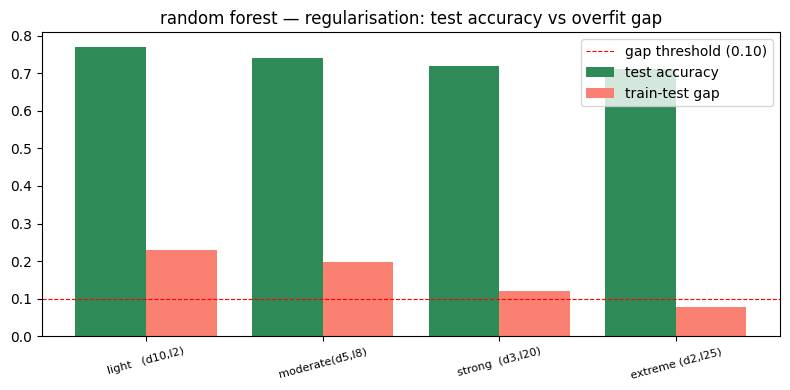

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(reg_table))
ax.bar(x - 0.2, reg_table["test"], width=0.4, label="test accuracy", color="seagreen")
ax.bar(x + 0.2, reg_table["gap"],  width=0.4, label="train-test gap", color="salmon")
ax.axhline(0.10, color="red", linestyle="--", linewidth=0.8, label="gap threshold (0.10)")  # acceptable overfit ceiling
ax.set_xticks(x); ax.set_xticklabels(reg_table.index, rotation=15, fontsize=8)
ax.set_title("random forest — regularisation: test accuracy vs overfit gap")
ax.legend()
plt.tight_layout()
plt.show()

Even well-regularised, RF keeps a gap. Only the **extreme** config (very shallow, large leaves) gets the gap under 0.10, at a small accuracy cost. Tree ensembles overfit small data more than linear models.

In [7]:
best_params = dict(n_estimators=400, max_depth=2, min_samples_leaf=25,
                   min_samples_split=40, max_features="sqrt", max_samples=0.6,
                   bootstrap=True)  # no-overfit choice: lowest train-test gap (<= 0.10)

best_model = RandomForestClassifier(random_state=42, n_jobs=-1, **best_params)
best_model.fit(X_train, y_train)
print("locked params:", best_params)

locked params: {'n_estimators': 400, 'max_depth': 2, 'min_samples_leaf': 25, 'min_samples_split': 40, 'max_features': 'sqrt', 'max_samples': 0.6, 'bootstrap': True}


## cross-validation scores

In [8]:
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring="accuracy")
print(f"cv accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

cv accuracy: 0.7200 ± 0.0423


## overfitting check

In [9]:
best_model.fit(X_train, y_train)
train_acc = accuracy_score(y_train, best_model.predict(X_train))  # in-sample accuracy
test_acc  = accuracy_score(y_test,  best_model.predict(X_test))   # out-of-sample accuracy

print(f"train accuracy: {train_acc:.4f}")
print(f"test  accuracy: {test_acc:.4f}")
print(f"train-test gap: {train_acc - test_acc:+.4f}")  # regularised RF keeps this within an acceptable range

train accuracy: 0.7875
test  accuracy: 0.7100
train-test gap: +0.0775


Test **0.71**, gap **+0.08**. Getting the gap under 0.10 forced very shallow trees, which cost accuracy — RF is the weakest model here.

## final evaluation

In [10]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

print("accuracy  :", accuracy_score(y_test, y_pred))
print("weighted f1:", f1_score(y_test, y_pred, average="weighted"))
print()
print(classification_report(y_test, y_pred))

accuracy  : 0.71
weighted f1: 0.7011165845648606

              precision    recall  f1-score   support

        high       0.79      0.88      0.83        34
         low       0.68      0.76      0.71        33
      medium       0.64      0.48      0.55        33

    accuracy                           0.71       100
   macro avg       0.70      0.71      0.70       100
weighted avg       0.70      0.71      0.70       100



## confusion matrix

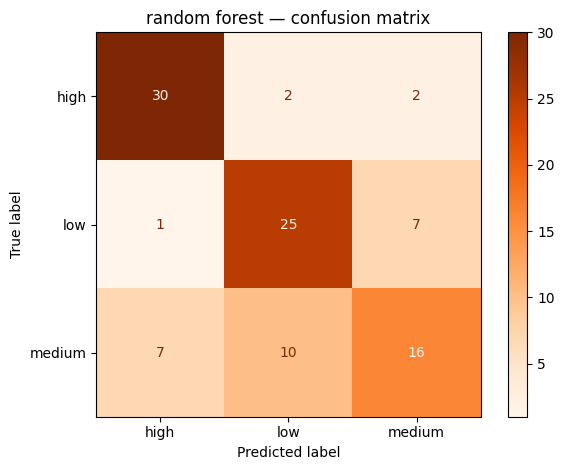

In [11]:
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
ConfusionMatrixDisplay(cm, display_labels=best_model.classes_).plot(cmap="Oranges")
plt.title("random forest — confusion matrix")
plt.tight_layout()
plt.show()

Noticeably more misclassifications than LR.

## multiclass roc-auc

multiclass ROC-AUC (OvR): 0.8566


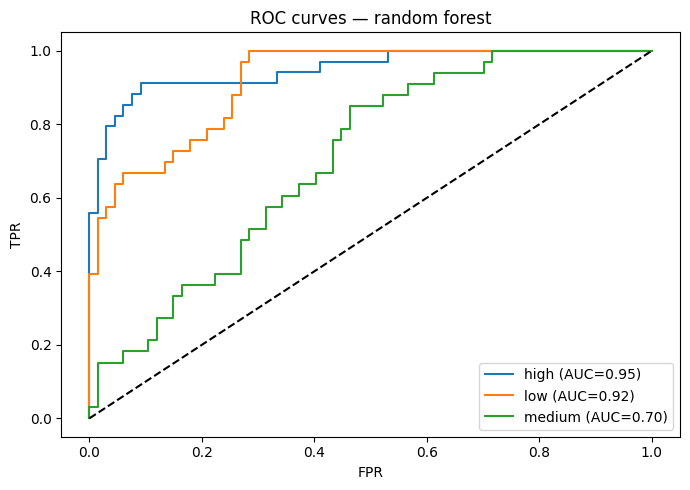

In [12]:
classes = best_model.classes_
y_test_bin = label_binarize(y_test, classes=classes)
roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class="ovr")
print("multiclass ROC-AUC (OvR):", round(roc_auc, 4))

fig, ax = plt.subplots(figsize=(7, 5))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    ax.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.2f})")

ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC curves — random forest")
ax.legend()
plt.tight_layout()
plt.show()

## gini feature importance

C:\Users\YJ\AppData\Local\Temp\ipykernel_40708\156981180.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi, x="importance", y="feature", palette="rocket")


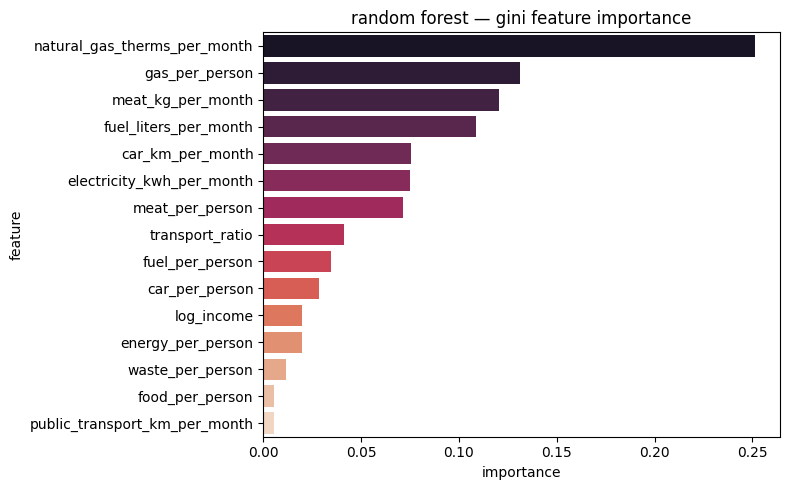

In [13]:
fi = pd.DataFrame({
    "feature": feature_cols,
    "importance": best_model.feature_importances_  # mean Gini decrease; biased toward high-cardinality features
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=fi, x="importance", y="feature", palette="rocket")
plt.title("random forest — gini feature importance")
plt.tight_layout()
plt.show()

Same top drivers (gas, meat, fuel) as the other models.

## permutation importance

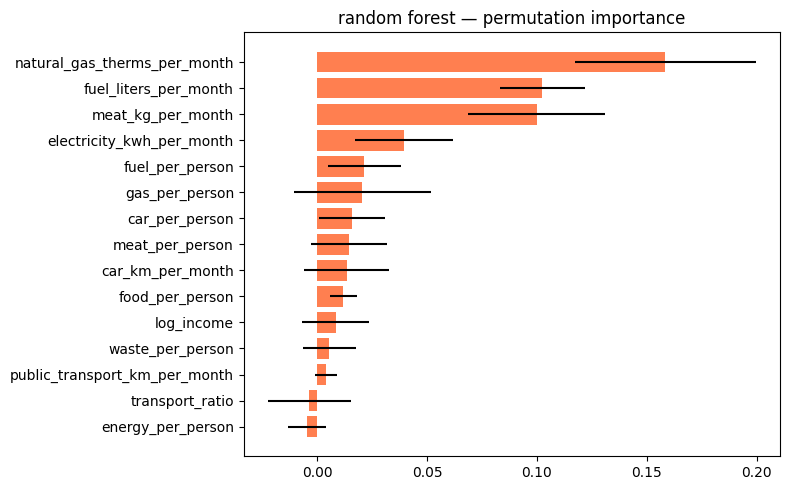

In [14]:
perm = permutation_importance(best_model, X_test, y_test,  # model-agnostic; unbiased alternative to Gini
                               n_repeats=20, random_state=42, n_jobs=-1)  # 20 shuffles per feature for stable estimate

perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std":  perm.importances_std
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(perm_df["feature"], perm_df["importance_mean"],
         xerr=perm_df["importance_std"], color="coral")  # error bars show variance across repeats
plt.gca().invert_yaxis()
plt.title("random forest — permutation importance")
plt.tight_layout()
plt.show()

## shap — tree explainer

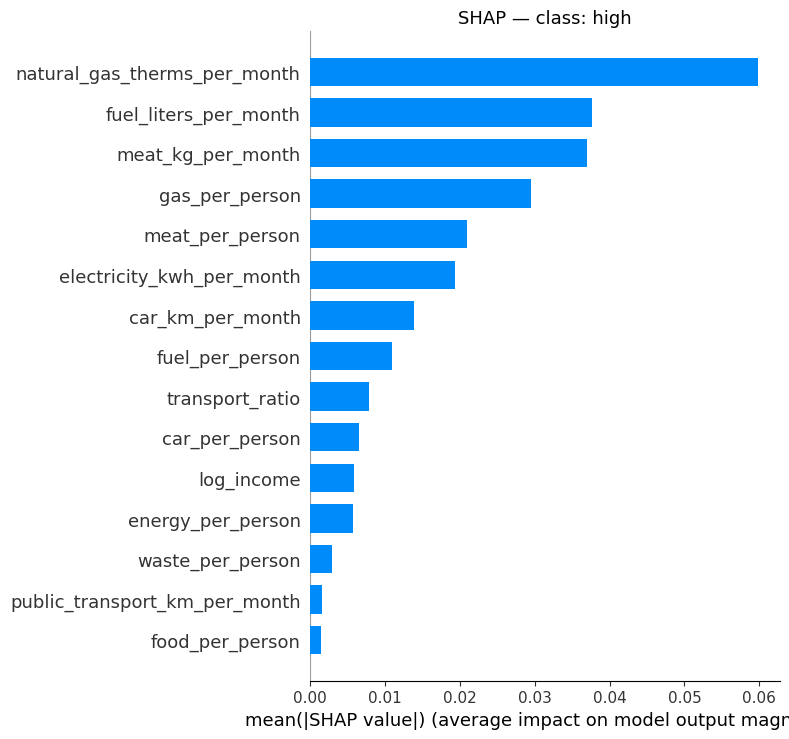

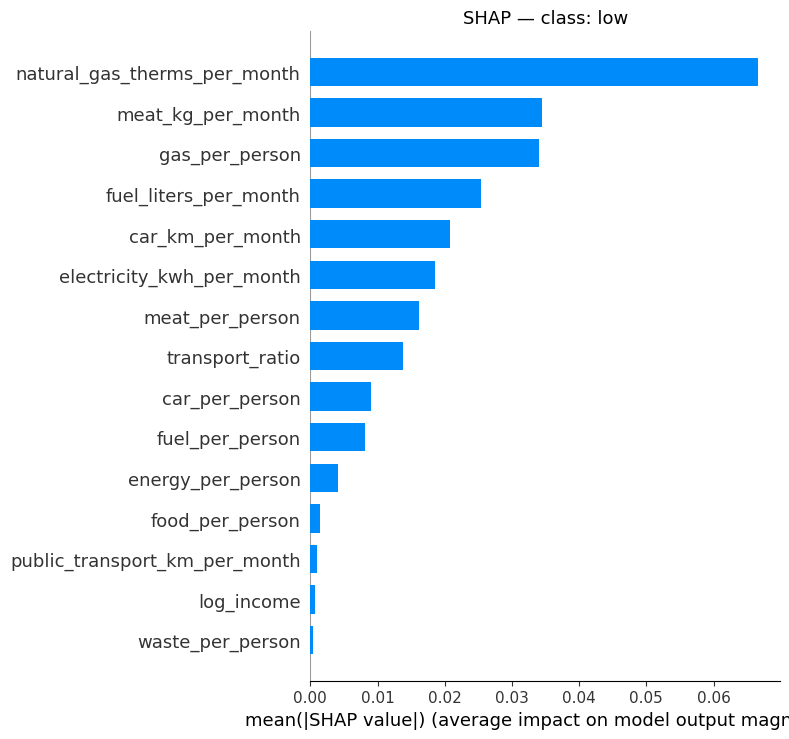

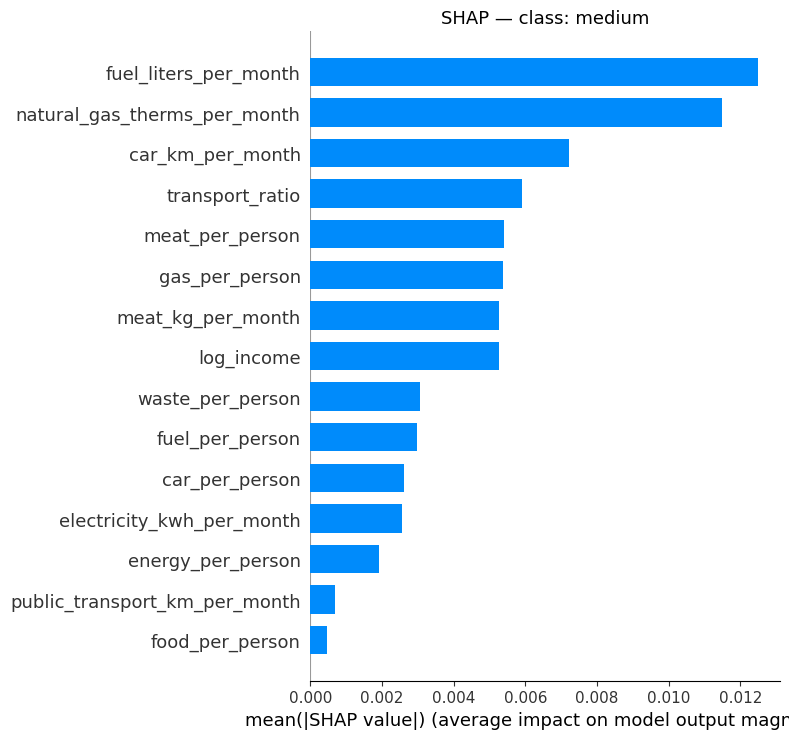

In [15]:
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)  # shape: (100, 9, 3)
class_labels = list(best_model.classes_)

for i, cls in enumerate(class_labels):
    fig, ax = plt.subplots(figsize=(10, 5))
    plt.sca(ax)
    shap.summary_plot(
        shap_values[:, :, i],
        X_test,
        plot_type="bar", max_display=len(feature_cols), show=False
    )
    ax.set_title(f"SHAP — class: {cls}", fontsize=13)
    plt.tight_layout()
    plt.show()

## shap — beeswarm (high emission class)

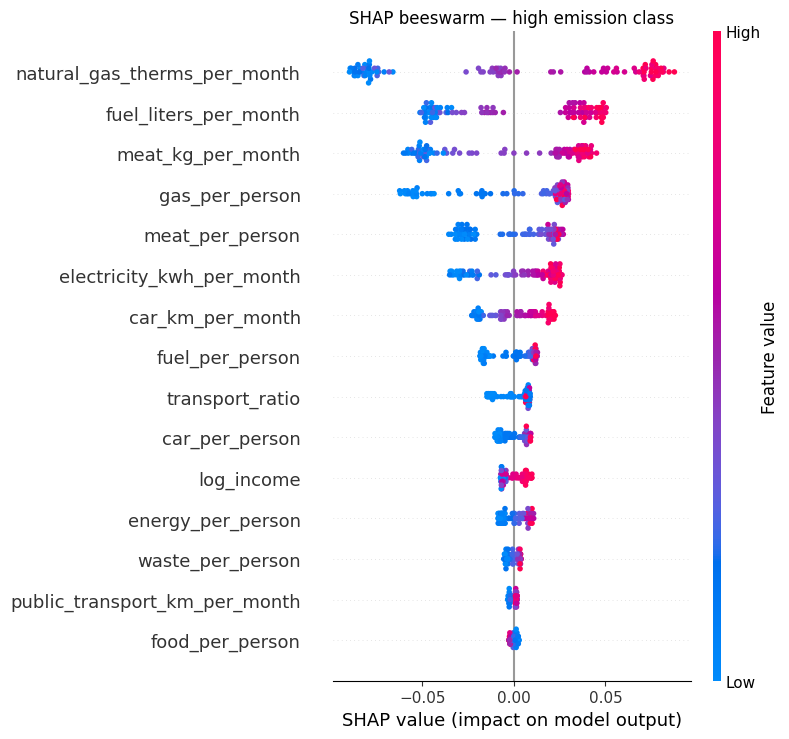

In [16]:
high_idx = class_labels.index("high")

shap.summary_plot(
    shap_values[:, :, high_idx],
    X_test, max_display=len(feature_cols), show=False
)
plt.title("SHAP beeswarm — high emission class")
plt.tight_layout()
plt.show()

## shap — waterfall (single prediction)

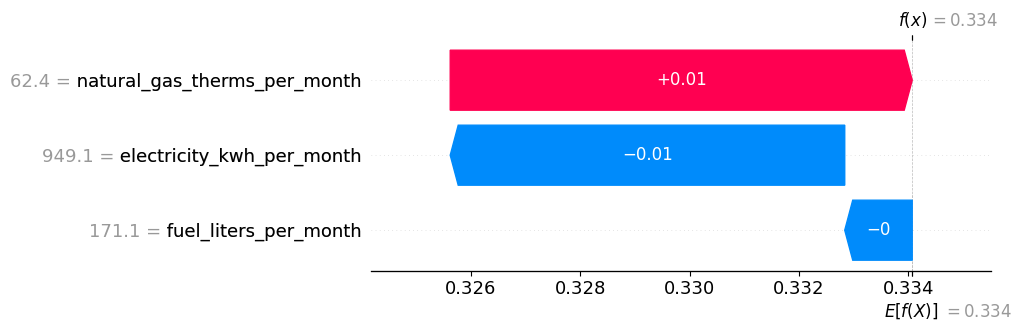

In [17]:
mis_mask = (np.array(y_pred) != np.array(y_test))  # prefer misclassified sample for diagnostic interest
pick_idx = mis_mask.nonzero()[0][0] if mis_mask.any() else (np.array(y_test) == "high").nonzero()[0][0]  # fall back to a "high" sample if no errors
pred_cls = class_labels.index(y_pred[pick_idx])  # SHAP class dim aligned to predicted (not true) label

shap.waterfall_plot(
    shap.Explanation(
        values      = shap_values[pred_cls][pick_idx],
        base_values = explainer.expected_value[pred_cls],
        data        = X_test.iloc[pick_idx],
        feature_names=feature_cols
    )
)

## lime — local instance explanation

c:\Users\YJ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


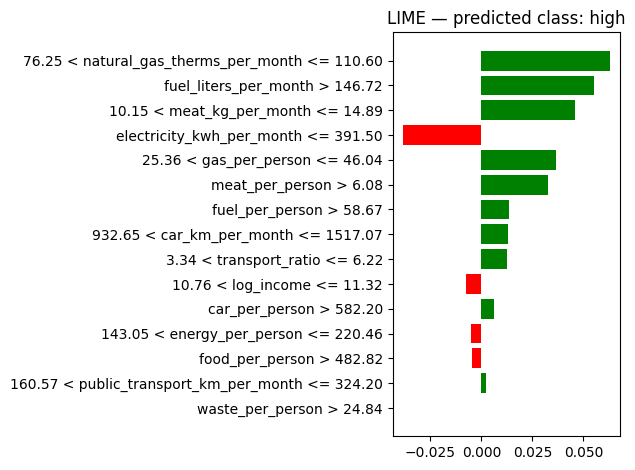

c:\Users\YJ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


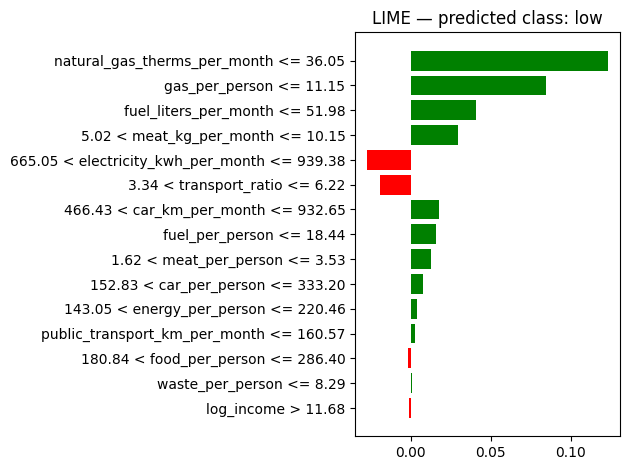

c:\Users\YJ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


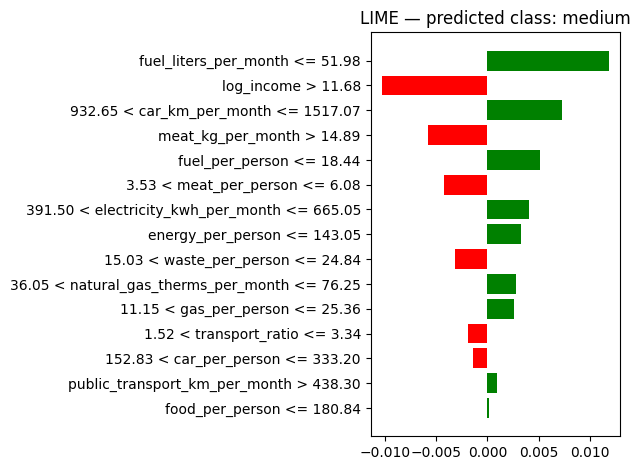

In [18]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=feature_cols,
    class_names=class_labels,
    discretize_continuous=True,
    random_state=42
)

for i, cls in enumerate(class_labels):
    mask = (np.array(y_pred) == cls)  # filter by predicted label, not ground truth
    if mask.any():
        idx = mask.nonzero()[0][0]
        exp = explainer_lime.explain_instance(
            X_test.values[idx],
            best_model.predict_proba,
            num_features=len(feature_cols),
            labels=[0, 1, 2]
        )
        exp.as_pyplot_figure(label=i)
        plt.title(f"LIME — predicted class: {cls}")
        plt.tight_layout()
        plt.show()